In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

## Graph size

In [ ]:
data = """
data/scerevisiae8_graphs_k11/:
total 82712
-rw-r--r-- 1 fpautet cifs-seqbio 30199251 Jun  6 10:18 n8_k11.bin
-rw-r--r-- 1 fpautet cifs-seqbio 54497011 Jun  6 10:18 n8_k11.fna

data/scerevisiae8_graphs_k13/:
total 330433
-rw-r--r-- 1 fpautet cifs-seqbio 116348476 Jun  6 10:19 n8_k13.bin
-rw-r--r-- 1 fpautet cifs-seqbio 222014397 Jun  6 10:18 n8_k13.fna

data/scerevisiae8_graphs_k15/:
total 262900
-rw-r--r-- 1 fpautet cifs-seqbio  33448648 Jun  6 09:47 n1_k15.bin
-rw-r--r-- 1 fpautet cifs-seqbio  69396210 Jun  6 09:47 n1_k15.fna
-rw-r--r-- 1 fpautet cifs-seqbio  54574785 Jun  6 10:19 n8_k15.bin
-rw-r--r-- 1 fpautet cifs-seqbio 111788674 Jun  6 10:19 n8_k15.fna

data/scerevisiae8_graphs_k17/:
total 62841
-rw-r--r-- 1 fpautet cifs-seqbio 19332711 Jun  6 10:20 n8_k17.bin
-rw-r--r-- 1 fpautet cifs-seqbio 45015162 Jun  6 10:20 n8_k17.fna

data/scerevisiae8_graphs_k19/:
total 50172
-rw-r--r-- 1 fpautet cifs-seqbio 14617736 Jun  6 10:20 n8_k19.bin
-rw-r--r-- 1 fpautet cifs-seqbio 36757213 Jun  6 10:20 n8_k19.fna

data/scerevisiae8_graphs_k21/:
total 49609
-rw-r--r-- 1 fpautet cifs-seqbio 14168304 Jun  6 10:21 n8_k21.bin
-rw-r--r-- 1 fpautet cifs-seqbio 36630264 Jun  6 10:21 n8_k21.fna

data/scerevisiae8_graphs_k23/:
total 50675
-rw-r--r-- 1 fpautet cifs-seqbio 14287721 Jun  6 10:20 n8_k23.bin
-rw-r--r-- 1 fpautet cifs-seqbio 37603176 Jun  6 10:20 n8_k23.fna

data/scerevisiae8_graphs_k25/:
total 51941
-rw-r--r-- 1 fpautet cifs-seqbio 14481251 Jun  6 10:21 n8_k25.bin
-rw-r--r-- 1 fpautet cifs-seqbio 38705948 Jun  6 10:21 n8_k25.fna

data/scerevisiae8_graphs_k27/:
total 53264
-rw-r--r-- 1 fpautet cifs-seqbio 14698916 Jun  6 10:21 n8_k27.bin
-rw-r--r-- 1 fpautet cifs-seqbio 39842525 Jun  6 10:21 n8_k27.fna

data/scerevisiae8_graphs_k29/:
total 54731
-rw-r--r-- 1 fpautet cifs-seqbio 14966920 Jun  6 10:21 n8_k29.bin
-rw-r--r-- 1 fpautet cifs-seqbio 41077136 Jun  6 10:21 n8_k29.fna

data/scerevisiae8_graphs_k31/:
total 310578
-rw-r--r-- 1 fpautet cifs-seqbio  3088900 Jun  5 13:32 n1_k31.bin
-rw-r--r-- 1 fpautet cifs-seqbio 11977448 Jun  5 13:32 n1_k31.fna
-rw-r--r-- 1 fpautet cifs-seqbio  7675951 Jun  5 13:35 n2_k31.bin
-rw-r--r-- 1 fpautet cifs-seqbio 23503413 Jun  5 13:35 n2_k31.fna
-rw-r--r-- 1 fpautet cifs-seqbio  9367992 Jun  5 13:38 n3_k31.bin
-rw-r--r-- 1 fpautet cifs-seqbio 27715222 Jun  5 13:38 n3_k31.fna
-rw-r--r-- 1 fpautet cifs-seqbio  9391426 Jun  5 13:41 n4_k31.bin
-rw-r--r-- 1 fpautet cifs-seqbio 27775867 Jun  5 13:41 n4_k31.fna
-rw-r--r-- 1 fpautet cifs-seqbio  9828655 Jun  5 13:44 n5_k31.bin
-rw-r--r-- 1 fpautet cifs-seqbio 28863130 Jun  5 13:44 n5_k31.fna
-rw-r--r-- 1 fpautet cifs-seqbio 12485507 Jun  5 13:47 n6_k31.bin
-rw-r--r-- 1 fpautet cifs-seqbio 35492002 Jun  5 13:47 n6_k31.fna
-rw-r--r-- 1 fpautet cifs-seqbio 14047482 Jun  5 13:50 n7_k31.bin
-rw-r--r-- 1 fpautet cifs-seqbio 39366625 Jun  5 13:50 n7_k31.fna
-rw-r--r-- 1 fpautet cifs-seqbio 15207741 Jun  6 10:22 n8_k31.bin
-rw-r--r-- 1 fpautet cifs-seqbio 42240118 Jun  6 10:22 n8_k31.fna

data/scerevisiae8_graphs_k9/:
total 5044
-rw-r--r-- 1 fpautet cifs-seqbio 1998897 Jun  6 10:18 n8_k9.bin
-rw-r--r-- 1 fpautet cifs-seqbio 3165690 Jun  6 10:18 n8_k9.fna

"""

rows = []
for line in data.strip().split('\n'):
    match = re.search(r'(\d+)\s+\S+\s+\S+\s+\S+\s+\S*n(\d+)_k(\d+)\.(bin|fna)', line)
    if match:
        size, n, k, filetype = match.groups()
        rows.append({'n': int(n), 'k': int(k), 'filetype': filetype, 'filesize': int(size)})

df_files = pd.DataFrame(rows)
df_files.sort_values(by=['k','n'], inplace=True)

In [92]:
data = """
Stats for graph "data/scerevisiae8_graphs/n8_k9.bin"Graph contains:        - 131072 nodes          - 524288 edges       Average node length: 9
Stats for graph "data/scerevisiae8_graphs/n8_k11.bin"Graph contains:       - 1917314 nodes         - 7231936 edges      Average node length: 11.00313720131392
Stats for graph "data/scerevisiae8_graphs/n8_k13.bin"Graph contains:       - 7125535 nodes         - 18026126 edges     Average node length: 13.31350937157701
Stats for graph "data/scerevisiae8_graphs/n8_k15.bin"Graph contains:       - 3099976 nodes         - 5806173 edges    Average node length: 18.41955099007218
Stats for graph "data/scerevisiae8_graphs/n8_k17.bin"Graph contains:       - 920750 nodes          - 1444726 edges    Average node length: 31.986577246809667
Stats for graph "data/scerevisiae8_graphs/n8_k19.bin"Graph contains:       - 618211 nodes          - 875467 edges       Average node length: 42.58056715263882
Stats for graph "data/scerevisiae8_graphs/n8_k21.bin"Graph contains:       - 570491 nodes          - 787782 edges       Average node length: 47.34073105447764
Stats for graph "data/scerevisiae8_graphs/n8_k23.bin"Graph contains:       - 556352 nodes          - 758179 edges       Average node length: 50.7239589324744
Stats for graph "data/scerevisiae8_graphs/n8_k25.bin"Graph contains:       - 546970 nodes          - 742457 edges     Average node length: 53.9012413843538
Stats for graph "data/scerevisiae8_graphs/n8_k27.bin"Graph contains:       - 539383 nodes          - 732449 edges       Average node length: 57.00501869728931
Stats for graph "data/scerevisiae8_graphs/n8_k29.bin"Graph contains:       - 534755 nodes          - 722579 edges       Average node length: 59.95306822750605
Stats for graph "data/scerevisiae8_graphs/n8_k31.bin"Graph contains:       - 529076 nodes          - 714204 edges     Average node length: 62.97546666263448

Stats for graph "data/scerevisiae8_graphs/n1_k31.bin"Graph contains:       - 10287 nodes           - 14507 edges      Average node length: 1149.0694079906677
Stats for graph "data/scerevisiae8_graphs/n2_k31.bin"Graph contains:       - 203686 nodes          - 273923 edges       Average node length: 98.73978574865234
Stats for graph "data/scerevisiae8_graphs/n3_k31.bin"Graph contains:       - 276739 nodes          - 372565 edges       Average node length: 83.40468817188759
Stats for graph "data/scerevisiae8_graphs/n4_k31.bin"Graph contains:       - 277685 nodes          - 373912 edges       Average node length: 83.28098744980824
Stats for graph "data/scerevisiae8_graphs/n5_k31.bin"Graph contains:       - 296590 nodes          - 399546 edges     Average node length: 80.55469166189015
Stats for graph "data/scerevisiae8_graphs/n6_k31.bin"Graph contains:       - 410826 nodes          - 553769 edges     Average node length: 69.56439709268645
Stats for graph "data/scerevisiae8_graphs/n7_k31.bin"Graph contains:       - 478605 nodes          - 645581 edges     Average node length: 65.40313828731418
Stats for graph "data/scerevisiae8_graphs/n8_k31.bin"Graph contains:       - 529076 nodes          - 714204 edges     Average node length: 62.97546666263448
"""

rows = []
for line in data.strip().split('\n'):
    r'(\d+)\s+\S+\s+\S+\s+\S+\s+\S*n(\d+)_k(\d+)\.(bin|fna)'
    match = re.search(r'n(\d+)_k(\d+)\.bin.*- (\d+) nodes.*- (\d+) edges.*Average node length: ([\d\.]+)', line)
    if match:
        n, k, nodes, edges, avg_length = match.groups()
        rows.append({'n': int(n), 'k': int(k), 'nodes': int(nodes), 'edges': int(edges), 'avg_length': float(avg_length)})
df_stats = pd.DataFrame(rows)
df_stats.sort_values(by=['k', 'n'], inplace=True)


In [95]:
df_merged = pd.merge(df_files, df_stats, on=['n', 'k'])

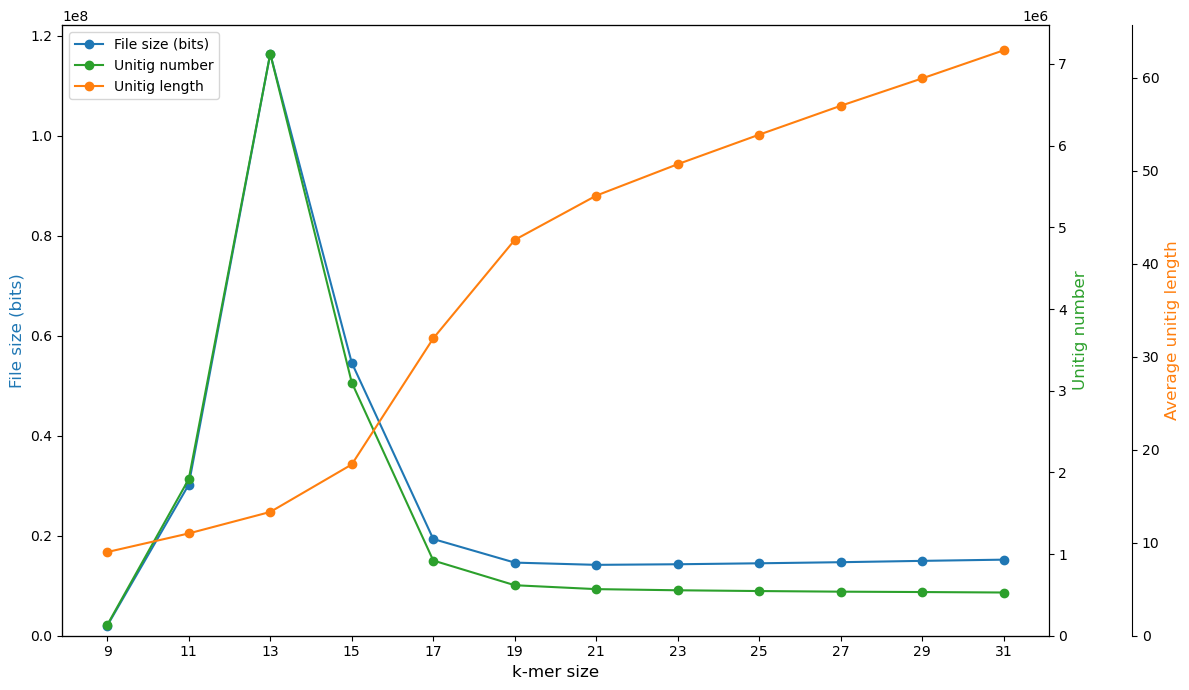

In [87]:
df = df_merged[(df_merged['filetype'] == 'bin') & (df_merged['n'] == 8)]
x = df['k']

fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

# Plot data
line1 = ax1.plot(x, df['filesize'], marker='o', color='tab:blue', label='File size (bits)')
# line1b = ax3.plot(x,  df_stats['avg_length']*df_stats['nodes'], marker='o', color='green', label='sizes')
line2 = ax2.plot(x, df['nodes'], marker='o', color='tab:green', label='Unitig number')
line3 = ax3.plot(x, df['avg_length'], marker='o', color='tab:orange', label='Unitig length')

ax1.set_ylabel('File size (bits)', color='tab:blue', fontsize=12)
ax2.set_ylabel('Unitig number', color='tab:green', fontsize=12)
ax3.set_ylabel('Average unitig length', color='tab:orange', fontsize=12)

# Set labels and colors
ax1.set_xticks(x)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax3.set_ylim(bottom=0)
ax1.set_xlabel('k-mer size', fontsize=12)

# Create combined legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

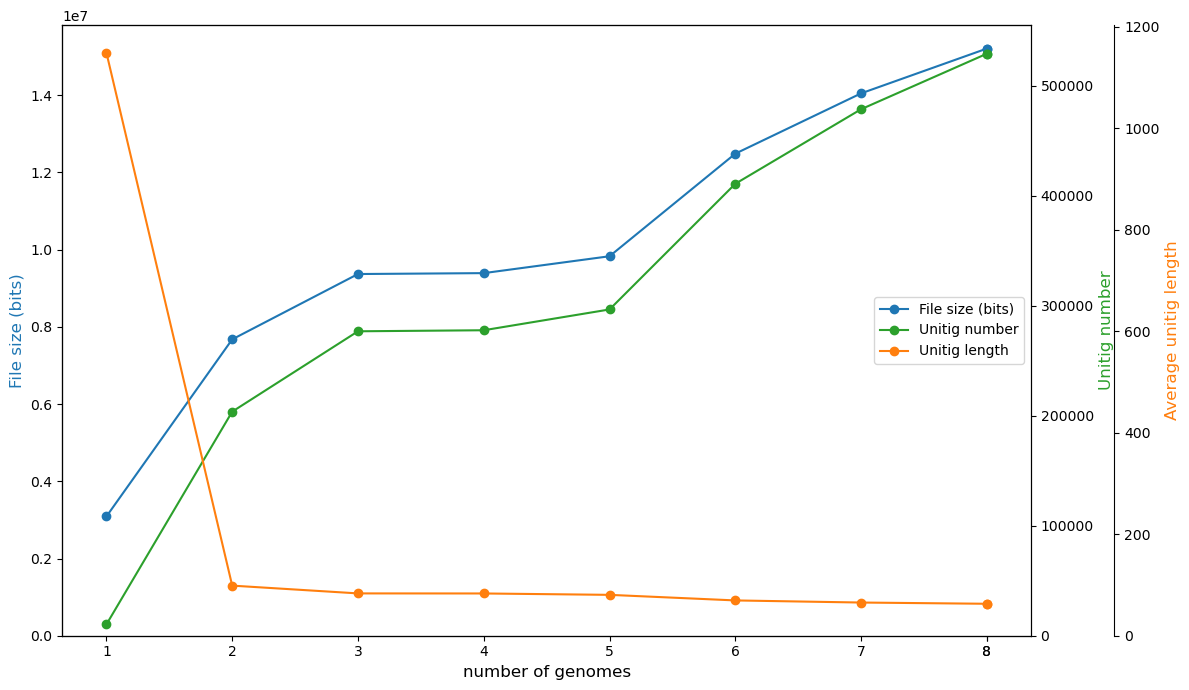

In [99]:
df = df_merged[(df_merged['filetype'] == 'bin') & (df_merged['k'] == 31)]
x = df['n']

fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

# Plot data
line1 = ax1.plot(x, df['filesize'], marker='o', color='tab:blue', label='File size (bits)')
# line1b = ax3.plot(x,  df_stats['avg_length']*df_stats['nodes'], marker='o', color='green', label='sizes')
line2 = ax2.plot(x, df['nodes'], marker='o', color='tab:green', label='Unitig number')
line3 = ax3.plot(x, df['avg_length'], marker='o', color='tab:orange', label='Unitig length')

ax1.set_ylabel('File size (bits)', color='tab:blue', fontsize=12)
ax2.set_ylabel('Unitig number', color='tab:green', fontsize=12)
ax3.set_ylabel('Average unitig length', color='tab:orange', fontsize=12)

# Set labels and colors
ax1.set_xticks(x)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax3.set_ylim(bottom=0)
ax1.set_xlabel('number of genomes', fontsize=12)

# Create combined legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Shortest path length

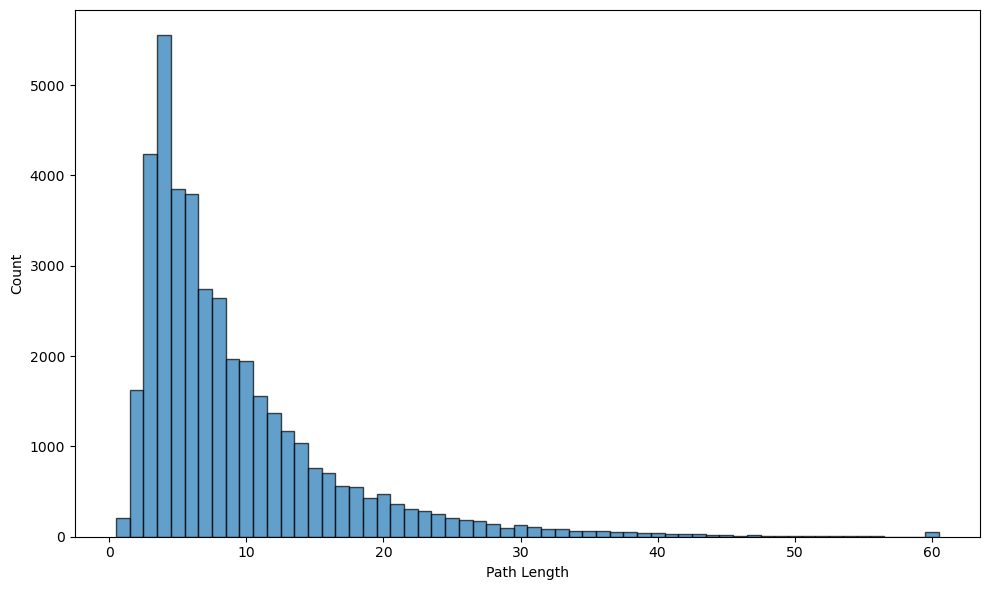

In [117]:
n = 8
path = f"data/SP_n{n}_k31.txt"

with open(path) as f:
    sp_series = pd.Series([int(line.strip().split(":")[1]) for line in f if line.strip()])


bins = np.arange(0.5, sp_series.max() + 1.5, 1)
plt.figure(figsize=(10, 6))
plt.hist(sp_series, bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Path Length')
plt.ylabel('Count')
# plt.title('Distribution of the path length')

plt.tight_layout()
plt.show()


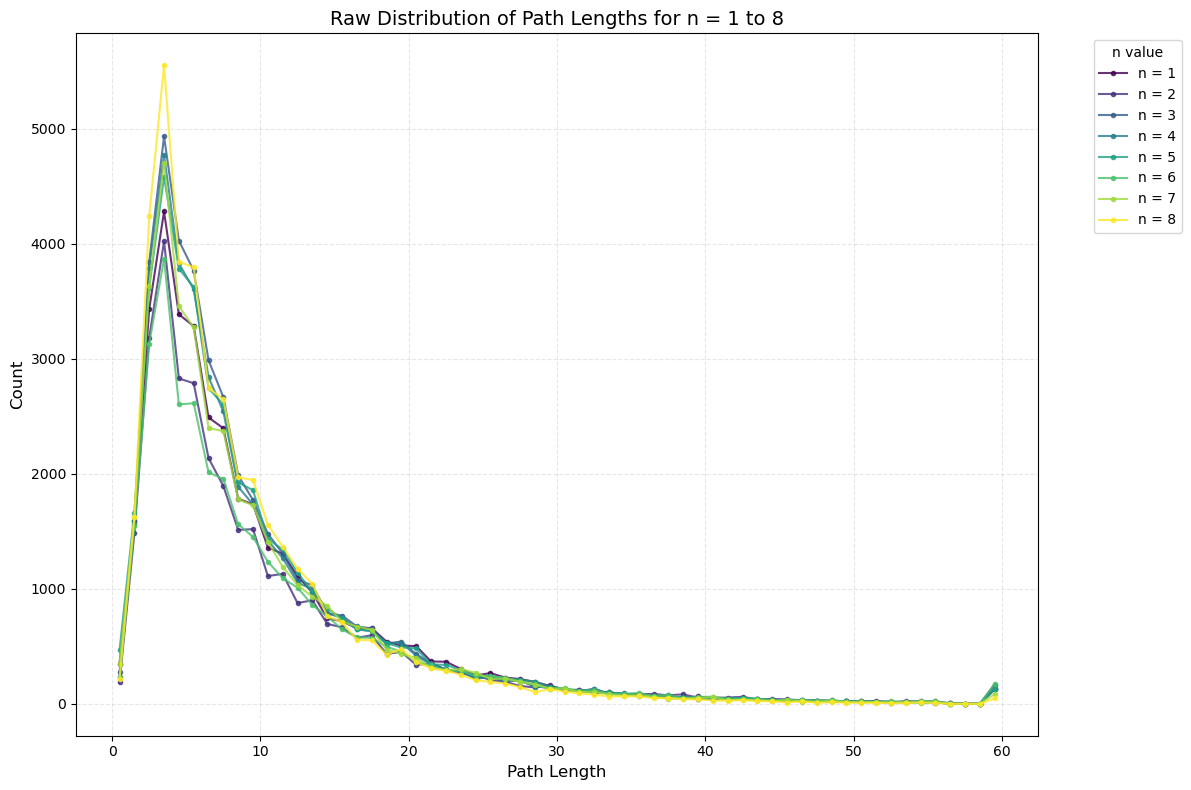

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Define colors for each n (1 to 8)
colors = plt.cm.viridis(np.linspace(0, 1, 8))

for n in range(1, 9):  # Loop from n=1 to n=8
    path = f"data/SP_n{n}_k31.txt"

    try:
        with open(path) as f:
            sp_series = pd.Series([int(line.strip().split(":")[1]) for line in f if line.strip()])

        # Compute histogram (raw counts)
        bins = np.arange(0.5, sp_series.max() + 1.5, 1)
        hist, bin_edges = np.histogram(sp_series, bins=bins)

        # Plot as a line (no smoothing)
        plt.plot(
            bin_edges[:-1],  # Use bin edges (left side)
            hist,
            color=colors[n-1],
            label=f'n = {n}',
            linewidth=1.5,
            alpha=0.8,
            marker='o',  # Optional: Add markers for clarity
            markersize=3
        )
    except FileNotFoundError:
        print(f"File not found: {path}")
        continue

# Customize the plot
plt.xlabel('Path Length', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Raw Distribution of Path Lengths for n = 1 to 8', fontsize=14)
plt.legend(title='n value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()